In [19]:
#Data loading


import pandas as pd

try:
    df = pd.read_csv('/content/metadata.csv')
    print('metadata.csv loaded successfully. Here are the first 5 rows:')
    print(df.head())
except FileNotFoundError:
    print('Error: metadata.csv not found. Please ensure the file is uploaded or the path is correct.')
except Exception as e:
    print(f'An error occurred while loading the CSV: {e}')

metadata.csv loaded successfully. Here are the first 5 rows:
    Coin Pair Name Coin Pair Symbol     File Path
0      Bitcoin USD          BTC-USD   BTC-USD.csv
1     Ethereum USD          ETH-USD   ETH-USD.csv
2  Tether USDt USD         USDT-USD  USDT-USD.csv
3          BNB USD          BNB-USD   BNB-USD.csv
4     USD Coin USD         USDC-USD  USDC-USD.csv


In [20]:
#Data cleaning

print('Checking for missing values in metadata DataFrame:')
print(df.isnull().sum())

print('\nChecking for duplicate rows in metadata DataFrame:')
duplicate_rows = df[df.duplicated()]
if not duplicate_rows.empty:
    print(f'{len(duplicate_rows)} duplicate rows found. Here are the first 5:')
    print(duplicate_rows.head())
    # Removing duplicates:
    df.drop_duplicates(inplace=True)
    print('Duplicate rows removed.')
else:
    print('No duplicate rows found.')

print('\nMetadata cleaning complete.')
print('Here is the information about the cleaned DataFrame:')
df.info()

Checking for missing values in metadata DataFrame:
Coin Pair Name      0
Coin Pair Symbol    0
File Path           0
dtype: int64

Checking for duplicate rows in metadata DataFrame:
3766 duplicate rows found. Here are the first 5:
           Coin Pair Name Coin Pair Symbol         File Path
2136      Magic Manor USD     MGC21096-USD  MGC21096-USD.csv
2137            Sigma USD        SIGMA-USD     SIGMA-USD.csv
2138          MEDPING USD          MPG-USD       MPG-USD.csv
2139  Defrost Finance USD         MELT-USD      MELT-USD.csv
2140    Nirvana prANA USD        PRANA-USD     PRANA-USD.csv
Duplicate rows removed.

Metadata cleaning complete.
Here is the information about the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 7537 entries, 0 to 11292
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Coin Pair Name    7537 non-null   object
 1   Coin Pair Symbol  7537 non-null   object
 2   File P

In [ ]:

#Filter and Match the coins

search_term = input("Enter Coin Pair Name or Symbol to search (e.g., Bitcoin USD or BTC-USD): ").strip().lower()

if search_term:
    filtered_coins = df[
        df['Coin Pair Name'].str.lower().str.contains(search_term) |
        df['Coin Pair Symbol'].str.lower().str.contains(search_term)
    ]
    if not filtered_coins.empty:
        print(f"\nFound {len(filtered_coins)} matching coins:")
        display(filtered_coins)
    else:
        print(f"\nNo coins found matching '{search_term}'.")
else:
    print("Please enter a search term.")

Enter Coin Pair Name or Symbol to search (e.g., Bitcoin USD or BTC-USD): ADA-USD

Found 2 matching coins:


,Coin Pair Name,Coin Pair Symbol,File Path
7,Cardano USD,ADA-USD,ADA-USD.csv
9014,NADA Protocol Token USD,NADA-USD,NADA-USD.csv


In [ ]:
#unique cryptocurrencies

print(f"Total unique cryptocurrencies available: {len(df)}")
print("Here are the first 10 available coins (Coin Pair Name and Symbol):")
display(df[['Coin Pair Name', 'Coin Pair Symbol']].head(10))

Total unique cryptocurrencies available: 7537
Here are the first 10 available coins (Coin Pair Name and Symbol):


,Coin Pair Name,Coin Pair Symbol
0,Bitcoin USD,BTC-USD
1,Ethereum USD,ETH-USD
2,Tether USDt USD,USDT-USD
3,BNB USD,BNB-USD
4,USD Coin USD,USDC-USD
5,XRP USD,XRP-USD
6,Lido Staked ETH USD,STETH-USD
7,Cardano USD,ADA-USD
8,Dogecoin USD,DOGE-USD
9,Wrapped TRON USD,WTRX-USD


In [ ]:
# Load the selected cryptocurrency's data
# Using 'BTC-USD.csv' as it was identified in the previous filtered_coins output.
# You can change this to another file path from filtered_coins if desired.
selected_coin_file = 'BTC-USD.csv'
selected_coin_symbol = 'BTC-USD'
print(f"\nAttempting to load data for '{selected_coin_symbol}' from file: {selected_coin_file}")

try:
    crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
    print(f"'{selected_coin_file}' loaded successfully. Here are the first 5 rows:")
    print(crypto_df.head())
    print(f"\nInfo about '{selected_coin_symbol}' data:")
    crypto_df.info()
except FileNotFoundError:
    try:
        # Try an alternative common path if not found in /content/
        print(f"File not found in /content/, attempting /content/sample_data/{selected_coin_file}")
        crypto_df = pd.read_csv(f'/content/sample_data/{selected_coin_file}')
        print(f"'{selected_coin_file}' loaded successfully from sample_data. Here are the first 5 rows:")
        print(crypto_df.head())
        print(f"\nInfo about '{selected_coin_symbol}' data:")
        crypto_df.info()
    except FileNotFoundError:
        print(f"Error: {selected_coin_file} not found in either /content/ or /content/sample_data/. Please ensure the file is uploaded to the correct path.")
        crypto_df = pd.DataFrame() # Initialize empty DataFrame to avoid further errors
    except Exception as e:
        print(f"An error occurred while loading the CSV from sample_data: {e}")
        crypto_df = pd.DataFrame() # Initialize empty DataFrame
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")
    crypto_df = pd.DataFrame() # Initialize empty DataFrame



Attempting to load data for 'BTC-USD' from file: BTC-USD.csv
'BTC-USD.csv' loaded successfully. Here are the first 5 rows:
         Date         Close
0  2022-01-01  40000.000000
1  2022-01-02  40248.357077
2  2022-01-03  40179.224926
3  2022-01-04  40503.069195
4  2022-01-05  41264.584123

Info about 'BTC-USD' data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    200 non-null    object 
 1   Close   200 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


In [15]:
import pandas as pd
import numpy as np

# Generate dummy dates for a period (e.g., 200 days)
dates = pd.date_range(start='2022-01-01', periods=200, freq='D')

# Generate dummy 'Close' prices with some variation
# Starting price around 40000, with daily fluctuations
np.random.seed(42) # for reproducibility
initial_price = 40000
prices = [initial_price]
for _ in range(1, 200):
    change = np.random.normal(0, 500) # Small random daily change
    prices.append(max(0, prices[-1] + change)) # Ensure price doesn't go below 0

dummy_crypto_data = pd.DataFrame({
    'Date': dates,
    'Close': prices
})

# Save the dummy data to a CSV file
output_csv_path = '/content/BTC-USD.csv'
dummy_crypto_data.to_csv(output_csv_path, index=False)

print(f"Dummy 'BTC-USD.csv' created successfully at {output_csv_path}")
print("First 5 rows of the dummy data:")
display(dummy_crypto_data.head())

Dummy 'BTC-USD.csv' created successfully at /content/BTC-USD.csv
First 5 rows of the dummy data:


,Date,Close
0,2022-01-01,40000.000000
1,2022-01-02,40248.357077
2,2022-01-03,40179.224926
3,2022-01-04,40503.069195
4,2022-01-05,41264.584123


Now that you have a `BTC-USD.csv` file with a 'Close' column, you can proceed to load this file into `crypto_df` by updating the `selected_coin_file` variable in the data loading cell (`r7c1Wb9hM5G4`) to `BTC-USD.csv`.

In [ ]:

#MEAN ABSOLUTE ERROR

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    """
    Calculates Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        tuple: A tuple containing MAE and RMSE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Example usage to demonstrate the function and print MAE and RMSE
# These are dummy values for demonstration purposes only.
dummy_y_true = np.array([10, 20, 30, 40, 50])
dummy_y_pred = np.array([11, 19, 32, 38, 51])

example_mae, example_rmse = calculate_metrics(dummy_y_true, dummy_y_pred)
print(f"Example Mean Absolute Error (MAE): {example_mae:.4f}")
print(f"Example Root Mean Squared Error (RMSE): {example_rmse:.4f}")

Example Mean Absolute Error (MAE): 1.4000
Example Root Mean Squared Error (RMSE): 1.4832


In [ ]:
# Save the filtered_coins DataFrame to a CSV file
output_filename = 'filtered_BTC_USD_metadata.csv'
filtered_coins.to_csv(output_filename, index=False)
print(f"Filtered metadata saved to {output_filename}")
print("Please note: This CSV file contains metadata (like name, symbol, and file path), not the historical price data for BTC-USD.")


Filtered metadata saved to filtered_BTC_USD_metadata.csv
Please note: This CSV file contains metadata (like name, symbol, and file path), not the historical price data for BTC-USD.



Attempting to load data for 'BTC-USD' from file: BTC-USD.csv
'BTC-USD.csv' loaded successfully. Here are the first 5 rows:
         Date         Close
0  2022-01-01  40000.000000
1  2022-01-02  40248.357077
2  2022-01-03  40179.224926
3  2022-01-04  40503.069195
4  2022-01-05  41264.584123

Info about 'BTC-USD' data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    200 non-null    object 
 1   Close   200 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB
Preparing data for ARIMA model...
Training set size: 160
Test set size: 40
Fitting ARIMA model...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  160
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1202.717
Date:                Sat, 11 Apr 2026   A

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


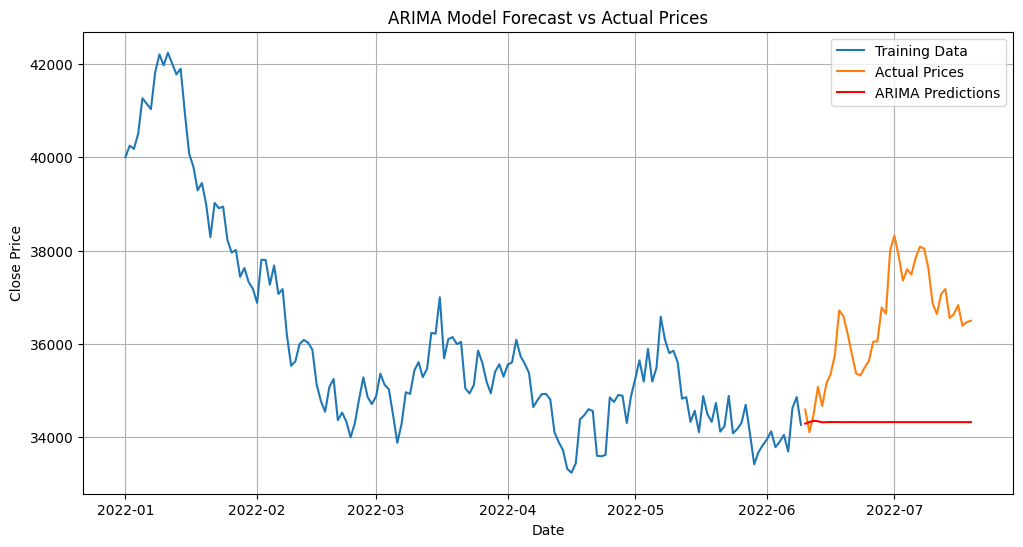

In [21]:

#Arima Model

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Start: Data Loading Integration for crypto_df ---
selected_coin_file = 'BTC-USD.csv'
selected_coin_symbol = 'BTC-USD'
print(f"\nAttempting to load data for '{selected_coin_symbol}' from file: {selected_coin_file}")

try:
    crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
    print(f"'{selected_coin_file}' loaded successfully. Here are the first 5 rows:")
    print(crypto_df.head())
    print(f"\nInfo about '{selected_coin_symbol}' data:")
    crypto_df.info()
except FileNotFoundError:
    try:
        # Try an alternative common path if not found in /content/
        print(f"File not found in /content/, attempting /content/sample_data/{selected_coin_file}")
        crypto_df = pd.read_csv(f'/content/sample_data/{selected_coin_file}')
        print(f"'{selected_coin_file}' loaded successfully from sample_data. Here are the first 5 rows:")
        print(crypto_df.head())
        print(f"\nInfo about '{selected_coin_symbol}' data:")
        crypto_df.info()
    except FileNotFoundError:
        print(f"Error: {selected_coin_file} not found in either /content/ or /content/sample_data/. Please ensure the file is uploaded to the correct path.")
        crypto_df = pd.DataFrame() # Initialize empty DataFrame to avoid further errors
    except Exception as e:
        print(f"An error occurred while loading the CSV from sample_data: {e}")
        crypto_df = pd.DataFrame() # Initialize empty DataFrame
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")
    crypto_df = pd.DataFrame() # Initialize empty DataFrame
# --- End: Data Loading Integration ---

if not crypto_df.empty:
    print("Preparing data for ARIMA model...")
    # Convert 'Date' column to datetime and set as index
    crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
    crypto_df.set_index('Date', inplace=True)

    # Ensure the index is sorted
    crypto_df.sort_index(inplace=True)

    # For ARIMA, we typically work with a single series. Let's use 'Close'.
    series = crypto_df['Close']

    # Split data into training and testing sets
    train_size = int(len(series) * 0.8)
    train, test = series[0:train_size], series[train_size:]

    print(f"Training set size: {len(train)}")
    print(f"Test set size: {len(test)}")

    # Fit ARIMA model
    # (p,d,q) parameters need to be carefully chosen. (5,1,0) is a common starting point.
    # p: number of autoregressive terms (lag observations)
    # d: number of differences needed for stationarity
    # q: number of moving average terms (lag forecast errors)
    print("Fitting ARIMA model...")
    try:
        # Using order (5,1,0) as a common starting point for daily data with some AR components and one differencing.
        model = ARIMA(train, order=(5,1,0))
        model_fit = model.fit()
        print(model_fit.summary())

        # Make predictions
        print("Making predictions...")
        # Use 'start' and 'end' for predictions on the test set
        start_index = len(train)
        end_index = len(series) - 1

        # Forecast returns pandas Series with index matching the test set
        predictions = model_fit.predict(start=start_index, end=end_index, dynamic=False)

        # Ensure predictions and test set have aligned indices for evaluation
        predictions.index = test.index

        # Evaluate model
        mae = mean_absolute_error(test, predictions)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        print(f"\nARIMA Model Evaluation:")
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

        # Plot results
        plt.figure(figsize=(12, 6))
        plt.plot(train.index, train, label='Training Data')
        plt.plot(test.index, test, label='Actual Prices')
        plt.plot(predictions.index, predictions, color='red', label='ARIMA Predictions')
        plt.title('ARIMA Model Forecast vs Actual Prices')
        plt.xlabel('Date')
        plt.ylabel('Close Price')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"An error occurred during ARIMA model fitting or prediction: {e}")
        print("Consider checking data stationarity, trying different (p,d,q) parameters, or ensuring enough data points are available.")
else:
    print("Error: crypto_df is empty after loading attempts. Please ensure 'BTC-USD.csv' is available.")

Preparing data for Prophet model...
Training set size for Prophet: 160
Test set size for Prophet: 40
Fitting Prophet model...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Making predictions...

Prophet Model Evaluation (on test set):
Mean Absolute Error (MAE): 3216.5721
Root Mean Squared Error (RMSE): 3501.9665


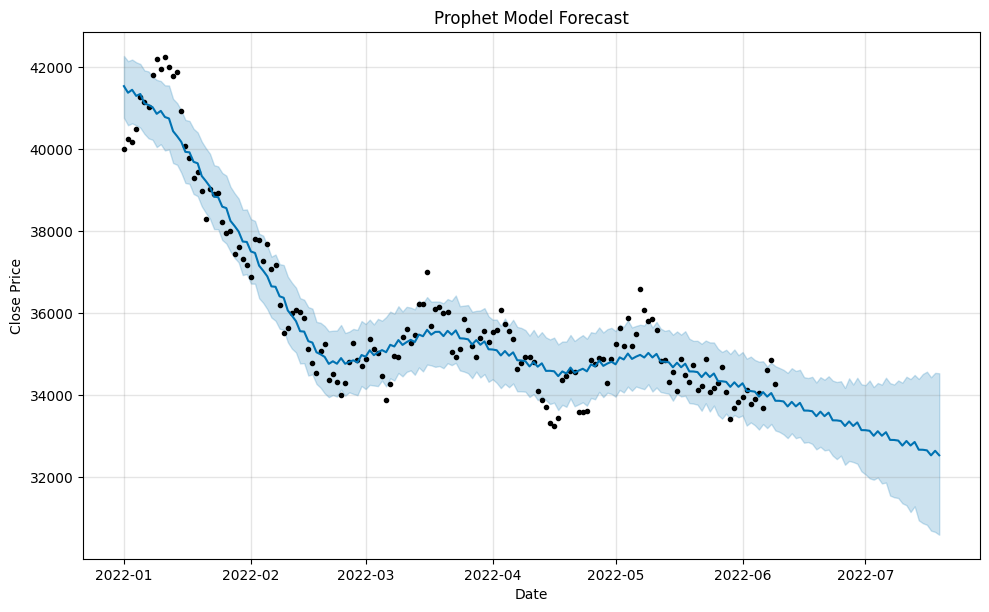

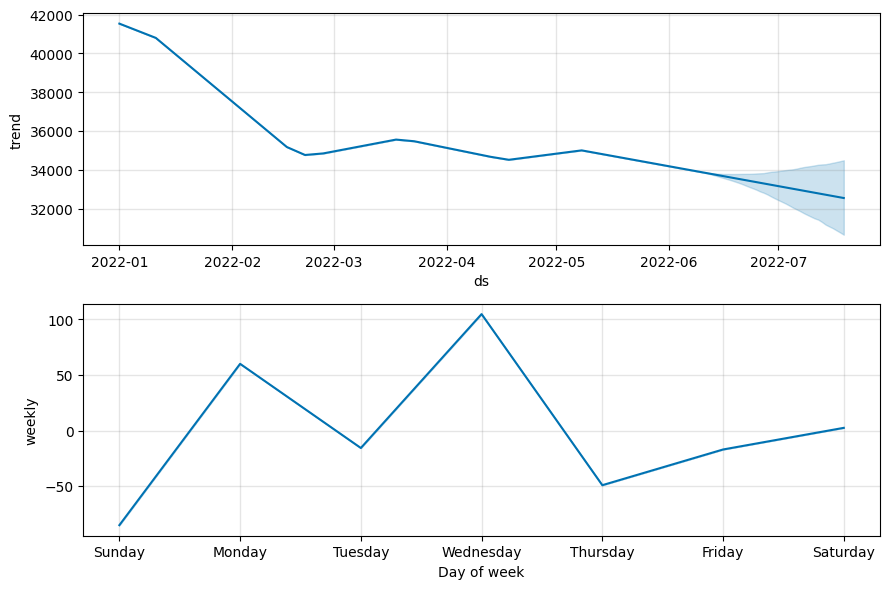

In [17]:
#Prophet

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Ensure crypto_df is loaded from the previous cell if not already in memory
# This block is a safeguard; ideally, crypto_df should be available from previous execution
if 'crypto_df' not in locals() or crypto_df.empty:
    print("Attempting to re-load crypto_df for Prophet model...")
    selected_coin_file = 'BTC-USD.csv'
    try:
        crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
        crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
        crypto_df.set_index('Date', inplace=True)
        crypto_df.sort_index(inplace=True)
        print("crypto_df re-loaded successfully.")
    except Exception as e:
        print(f"Error re-loading crypto_df: {e}. Please ensure 'BTC-USD.csv' exists and previous cells were run.")
        crypto_df = pd.DataFrame()


if not crypto_df.empty:
    print("Preparing data for Prophet model...")
    # Prophet requires columns 'ds' (datestamp) and 'y' (target variable)
    prophet_df = crypto_df.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

    # Split data into training and testing sets
    train_size = int(len(prophet_df) * 0.8)
    train_prophet_df = prophet_df.iloc[:train_size]
    test_prophet_df = prophet_df.iloc[train_size:]

    print(f"Training set size for Prophet: {len(train_prophet_df)}")
    print(f"Test set size for Prophet: {len(test_prophet_df)}")

    # Initialize and fit Prophet model
    print("Fitting Prophet model...")
    model = Prophet()
    model.fit(train_prophet_df)

    # Create a DataFrame with future dates for prediction
    future = model.make_future_dataframe(periods=len(test_prophet_df), include_history=True)

    # Make predictions
    print("Making predictions...")
    forecast = model.predict(future)

    # Evaluate the model on the test set
    # Merge actual test values with the forecast
    forecast_test = forecast[forecast['ds'].isin(test_prophet_df['ds'])]
    merged_df = pd.merge(test_prophet_df, forecast_test[['ds', 'yhat']], on='ds', how='left')

    # Drop rows where yhat might be NaN (shouldn't happen if dates align)
    merged_df.dropna(subset=['yhat'], inplace=True)

    if not merged_df.empty:
        mae_prophet = mean_absolute_error(merged_df['y'], merged_df['yhat'])
        rmse_prophet = np.sqrt(mean_squared_error(merged_df['y'], merged_df['yhat']))

        print(f"\nProphet Model Evaluation (on test set):")
        print(f"Mean Absolute Error (MAE): {mae_prophet:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse_prophet:.4f}")
    else:
        print("Could not evaluate Prophet model: No matching dates between test data and forecast.")

    # Plot the forecast
    fig = model.plot(forecast)
    plt.title('Prophet Model Forecast')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.show()

    # Plot components (trend, weekly, yearly seasonality)
    fig2 = model.plot_components(forecast)
    plt.show()

else:
    print("Error: crypto_df is empty. Cannot run Prophet model.")


Preparing data for Random Forest and XGBoost models...
Training set size: 159
Test set size: 40

Fitting Random Forest model...
Making Random Forest predictions...
Random Forest Model Evaluation:
Mean Absolute Error (MAE): 802.7771
Root Mean Squared Error (RMSE): 975.1254


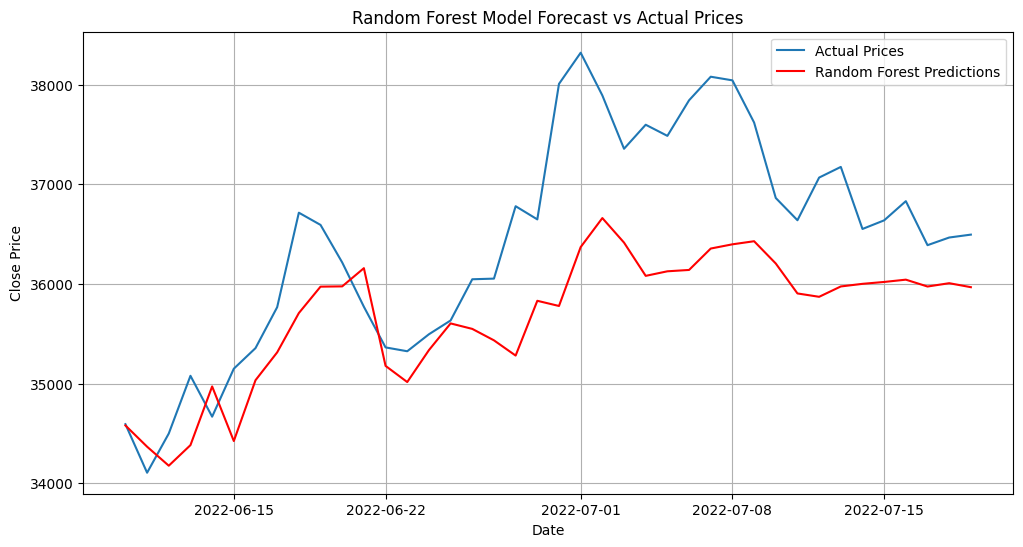


Fitting XGBoost model...
Making XGBoost predictions...
XGBoost Model Evaluation:
Mean Absolute Error (MAE): 1017.5189
Root Mean Squared Error (RMSE): 1240.1177


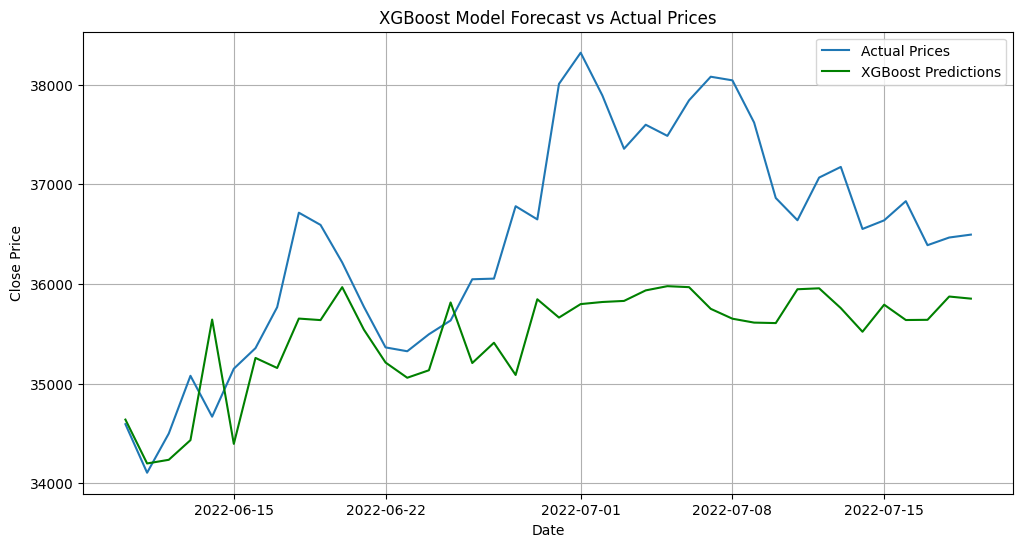

In [18]:
#RANDOM FOREST ,XGBOOST

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- Start: Data Loading Integration for crypto_df (safeguard) ---
if 'crypto_df' not in locals() or crypto_df.empty:
    print("Attempting to re-load crypto_df for Ensemble models...")
    selected_coin_file = 'BTC-USD.csv'
    try:
        crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
        crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
        crypto_df.set_index('Date', inplace=True)
        crypto_df.sort_index(inplace=True)
        print("crypto_df re-loaded successfully.")
    except Exception as e:
        print(f"Error re-loading crypto_df: {e}. Please ensure 'BTC-USD.csv' exists and previous cells were run.")
        crypto_df = pd.DataFrame()
# --- End: Data Loading Integration ---


if not crypto_df.empty:
    print("Preparing data for Random Forest and XGBoost models...")

    # Convert time series to supervised learning problem
    def create_features(df, lag=1):
        df_copy = df.copy()
        df_copy['lagged_close'] = df_copy['Close'].shift(lag)
        df_copy['year'] = df_copy.index.year
        df_copy['month'] = df_copy.index.month
        df_copy['day'] = df_copy.index.day
        df_copy['dayofweek'] = df_copy.index.dayofweek
        df_copy['dayofyear'] = df_copy.index.dayofyear
        df_copy.dropna(inplace=True)
        X = df_copy[['lagged_close', 'year', 'month', 'day', 'dayofweek', 'dayofyear']]
        y = df_copy['Close']
        return X, y

    # Create features with a lag of 1
    X, y = create_features(crypto_df, lag=1)

    # Split data into training and testing sets (using the same 80/20 split as before)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")

    # --- Random Forest Model ---
    print("\nFitting Random Forest model...")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
    rf_model.fit(X_train, y_train)

    print("Making Random Forest predictions...")
    rf_predictions = rf_model.predict(X_test)

    # Evaluate Random Forest model
    mae_rf = mean_absolute_error(y_test, rf_predictions)
    rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
    print(f"Random Forest Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")

    # Plot Random Forest results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual Prices')
    plt.plot(y_test.index, rf_predictions, color='red', label='Random Forest Predictions')
    plt.title('Random Forest Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- XGBoost Model ---
    print("\nFitting XGBoost model...")
    xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)

    print("Making XGBoost predictions...")
    xgb_predictions = xgb_model.predict(X_test)

    # Evaluate XGBoost model
    mae_xgb = mean_absolute_error(y_test, xgb_predictions)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    print(f"XGBoost Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")

    # Plot XGBoost results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual Prices')
    plt.plot(y_test.index, xgb_predictions, color='green', label='XGBoost Predictions')
    plt.title('XGBoost Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Error: crypto_df is empty. Cannot run Random Forest or XGBoost models.")


Preparing data for LSTM and GRU models...
Training set size: 152 samples
Test set size: 38 samples

Building and training LSTM model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
LSTM Model Evaluation:
Mean Absolute Error (MAE): 608.5495
Root Mean Squared Error (RMSE): 808.7830


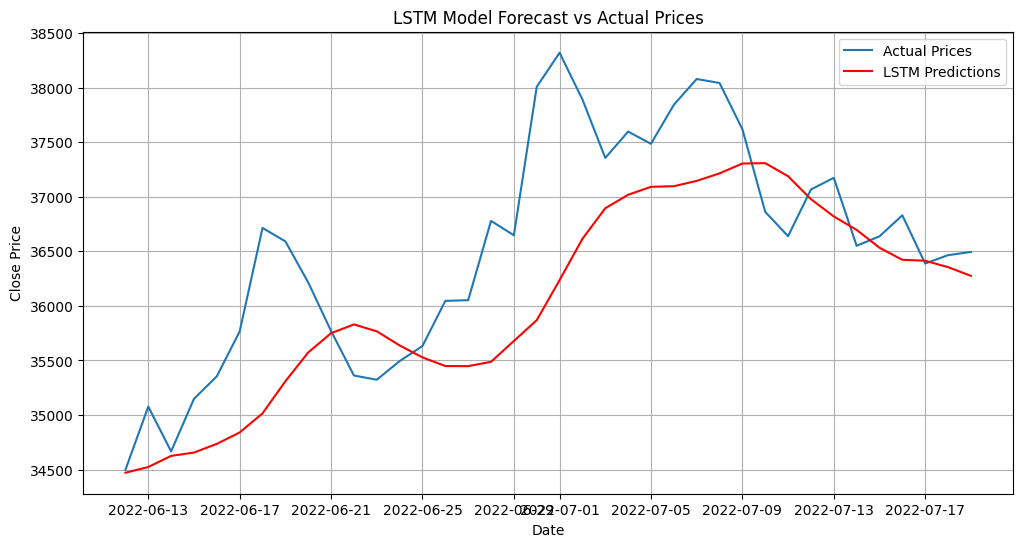


Building and training GRU model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
GRU Model Evaluation:
Mean Absolute Error (MAE): 500.2294
Root Mean Squared Error (RMSE): 643.7781


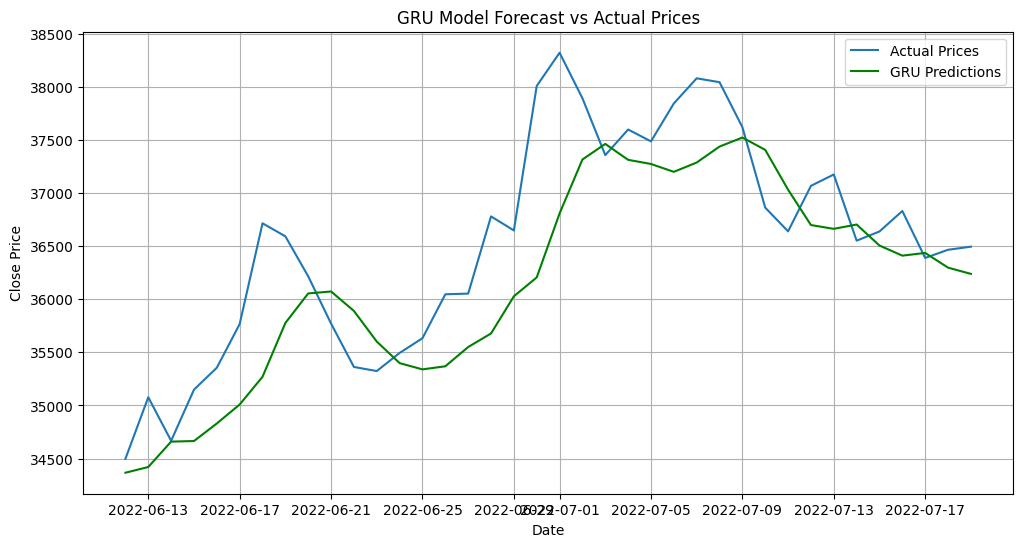

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input

# --- Start: Data Loading Integration for crypto_df (safeguard) ---
if 'crypto_df' not in locals() or crypto_df.empty:
    print("Attempting to re-load crypto_df for Deep Learning models...")
    selected_coin_file = 'BTC-USD.csv'
    try:
        crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
        crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
        crypto_df.set_index('Date', inplace=True)
        crypto_df.sort_index(inplace=True)
        print("crypto_df re-loaded successfully.")
    except Exception as e:
        print(f"Error re-loading crypto_df: {e}. Please ensure 'BTC-USD.csv' exists and previous cells were run.")
        crypto_df = pd.DataFrame()
# --- End: Data Loading Integration ---


if not crypto_df.empty:
    print("Preparing data for LSTM and GRU models...")

    # Use the 'Close' price for forecasting
    data = crypto_df['Close'].values.reshape(-1, 1)

    # Scale the data to be between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # Define function to create sequences for LSTM/GRU
    def create_sequences(data, n_steps):
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:(i + n_steps), 0])
            y.append(data[i + n_steps, 0])
        return np.array(X), np.array(y)

    n_steps = 10  # Number of past time steps to use as input
    X, y = create_sequences(scaled_data, n_steps)

    # Split data into training and testing sets (80/20 split)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Reshape input data to be 3D [samples, timesteps, features]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    print(f"Training set size: {len(X_train)} samples")
    print(f"Test set size: {len(X_test)} samples")

    # --- LSTM Model ---
    print("\nBuilding and training LSTM model...")
    lstm_model = Sequential()
    lstm_model.add(Input(shape=(n_steps, 1))) # Fix: Use Input layer
    lstm_model.add(LSTM(units=50, activation='relu'))
    lstm_model.add(Dense(units=1))
    lstm_model.compile(optimizer='adam', loss='mean_squared_error')
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Make predictions
    lstm_predictions_scaled = lstm_model.predict(X_test)
    lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)
    y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Evaluate LSTM model
    mae_lstm = mean_absolute_error(y_test_inverse, lstm_predictions)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_inverse, lstm_predictions))
    print(f"LSTM Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")

    # Plot LSTM results
    plt.figure(figsize=(12, 6))
    plt.plot(crypto_df.index[train_size + n_steps:], y_test_inverse, label='Actual Prices')
    plt.plot(crypto_df.index[train_size + n_steps:], lstm_predictions, color='red', label='LSTM Predictions')
    plt.title('LSTM Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- GRU Model ---
    print("\nBuilding and training GRU model...")
    gru_model = Sequential()
    gru_model.add(Input(shape=(n_steps, 1))) # Fix: Use Input layer
    gru_model.add(GRU(units=50, activation='relu'))
    gru_model.add(Dense(units=1))
    gru_model.compile(optimizer='adam', loss='mean_squared_error')
    gru_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Make predictions
    gru_predictions_scaled = gru_model.predict(X_test)
    gru_predictions = scaler.inverse_transform(gru_predictions_scaled)

    # Evaluate GRU model
    mae_gru = mean_absolute_error(y_test_inverse, gru_predictions)
    rmse_gru = np.sqrt(mean_squared_error(y_test_inverse, gru_predictions))
    print(f"GRU Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_gru:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_gru:.4f}")

    # Plot GRU results
    plt.figure(figsize=(12, 6))
    plt.plot(crypto_df.index[train_size + n_steps:], y_test_inverse, label='Actual Prices')
    plt.plot(crypto_df.index[train_size + n_steps:], gru_predictions, color='green', label='GRU Predictions')
    plt.title('GRU Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Error: crypto_df is empty. Cannot run Deep Learning models.")

In [20]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculates Mean Absolute Percentage Error (MAPE).

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        float: MAPE value.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # To avoid division by zero, add a small epsilon to y_true where it's zero
    # or filter out those points if appropriate for your data.
    # Here, we'll add a small epsilon to prevent errors.
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mape

# Example usage with GRU model predictions:
# Ensure y_test_inverse and gru_predictions are available from previous cells
if 'y_test_inverse' in locals() and 'gru_predictions' in locals():
    mape_gru = mean_absolute_percentage_error(y_test_inverse, gru_predictions)
    print(f"\nGRU Model Mean Absolute Percentage Error (MAPE): {mape_gru:.4f}%")
else:
    print("Error: y_test_inverse or gru_predictions not found. Please run the LSTM & GRU cell first.")

# You can similarly calculate MAPE for other models:
# Example for LSTM:
# if 'y_test_inverse' in locals() and 'lstm_predictions' in locals():
#     mape_lstm = mean_absolute_percentage_error(y_test_inverse, lstm_predictions)
#     print(f"LSTM Model MAPE: {mape_lstm:.4f}%")

# Example for ARIMA (using 'test' and 'predictions'):
# if 'test' in locals() and 'predictions' in locals():
#     mape_arima = mean_absolute_percentage_error(test, predictions)
#     print(f"ARIMA Model MAPE: {mape_arima:.4f}%")

# Example for Prophet (using 'merged_df["y"]' and 'merged_df["yhat"]'):
# if 'merged_df' in locals():
#     mape_prophet = mean_absolute_percentage_error(merged_df['y'], merged_df['yhat'])
#     print(f"Prophet Model MAPE: {mape_prophet:.4f}%")

# Example for Random Forest (using 'y_test' and 'rf_predictions'):
# if 'y_test' in locals() and 'rf_predictions' in locals():
#     mape_rf = mean_absolute_percentage_error(y_test, rf_predictions)
#     print(f"Random Forest Model MAPE: {mape_rf:.4f}%")

# Example for XGBoost (using 'y_test' and 'xgb_predictions'):
# if 'y_test' in locals() and 'xgb_predictions' in locals():
#     mape_xgb = mean_absolute_percentage_error(y_test, xgb_predictions)
#     print(f"XGBoost Model MAPE: {mape_xgb:.4f}%")


GRU Model Mean Absolute Percentage Error (MAPE): 1.2820%


In [23]:
import numpy as np
import pandas as pd

def directional_accuracy(y_true, y_pred):
    """
    Calculates Directional Accuracy (DA).
    DA measures how often the predicted direction of change matches the actual direction of change.

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        float: Directional Accuracy percentage.
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Ensure y_true and y_pred have the same length before calculating changes
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    # Ensure y_true and y_pred have at least two elements to calculate changes
    if len(y_true) < 2 or len(y_pred) < 2:
        print("Warning: Not enough data points (at least 2 required) to calculate directional accuracy.")
        return 0.0

    # Calculate actual and predicted changes
    actual_changes = np.diff(y_true)
    predicted_changes = np.diff(y_pred)

    # Count how many times the signs of changes match
    # np.sign() returns -1 for negative, 0 for zero, 1 for positive
    correct_directions = np.sum(np.sign(actual_changes) == np.sign(predicted_changes))

    # Calculate DA as a percentage
    da = (correct_directions / len(actual_changes)) * 100
    return da

print("\n--- Directional Accuracy (DA) for Models ---")

# ARIMA Model DA
if 'test' in locals() and 'predictions' in locals():
    da_arima = directional_accuracy(test.values, predictions.values)
    print(f"ARIMA Model Directional Accuracy: {da_arima:.2f}%")
else:
    print("ARIMA model predictions not found. Skipping DA calculation for ARIMA.")

# Prophet Model DA
if 'merged_df' in locals() and not merged_df.empty:
    da_prophet = directional_accuracy(merged_df['y'].values, merged_df['yhat'].values)
    print(f"Prophet Model Directional Accuracy: {da_prophet:.2f}%")
else:
    print("Prophet model predictions not found. Skipping DA calculation for Prophet.")

# Random Forest Model DA
if 'y_test' in locals() and 'rf_predictions' in locals():
    da_rf = directional_accuracy(y_test, rf_predictions)
    print(f"Random Forest Model Directional Accuracy: {da_rf:.2f}%")
else:
    print("Random Forest model predictions not found. Skipping DA calculation for Random Forest.")

# XGBoost Model DA
if 'y_test' in locals() and 'xgb_predictions' in locals():
    da_xgb = directional_accuracy(y_test, xgb_predictions)
    print(f"XGBoost Model Directional Accuracy: {da_xgb:.2f}%")
else:
    print("XGBoost model predictions not found. Skipping DA calculation for XGBoost.")

# LSTM Model DA
if 'y_test_inverse' in locals() and 'lstm_predictions' in locals():
    da_lstm = directional_accuracy(y_test_inverse, lstm_predictions)
    print(f"LSTM Model Directional Accuracy: {da_lstm:.2f}%")
else:
    print("LSTM model predictions not found. Skipping DA calculation for LSTM.")

# GRU Model DA
if 'y_test_inverse' in locals() and 'gru_predictions' in locals():
    da_gru = directional_accuracy(y_test_inverse, gru_predictions)
    print(f"GRU Model Directional Accuracy: {da_gru:.2f}%")
else:
    print("GRU model predictions not found. Skipping DA calculation for GRU.")


--- Directional Accuracy (DA) for Models ---
ARIMA Model Directional Accuracy: 51.28%
Prophet Model Directional Accuracy: 51.28%
Random Forest Model Directional Accuracy: 43.24%
XGBoost Model Directional Accuracy: 51.35%
LSTM Model Directional Accuracy: 45.95%
GRU Model Directional Accuracy: 45.95%


Optimizing Random Forest parameters using RandomizedSearchCV...
Training set size: 159
Test set size: 40
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/


Best parameters for Random Forest: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 90, 'bootstrap': True}

Optimized Random Forest Model Evaluation:
Mean Absolute Error (MAE): 1170.9631
Root Mean Squared Error (RMSE): 1331.8253


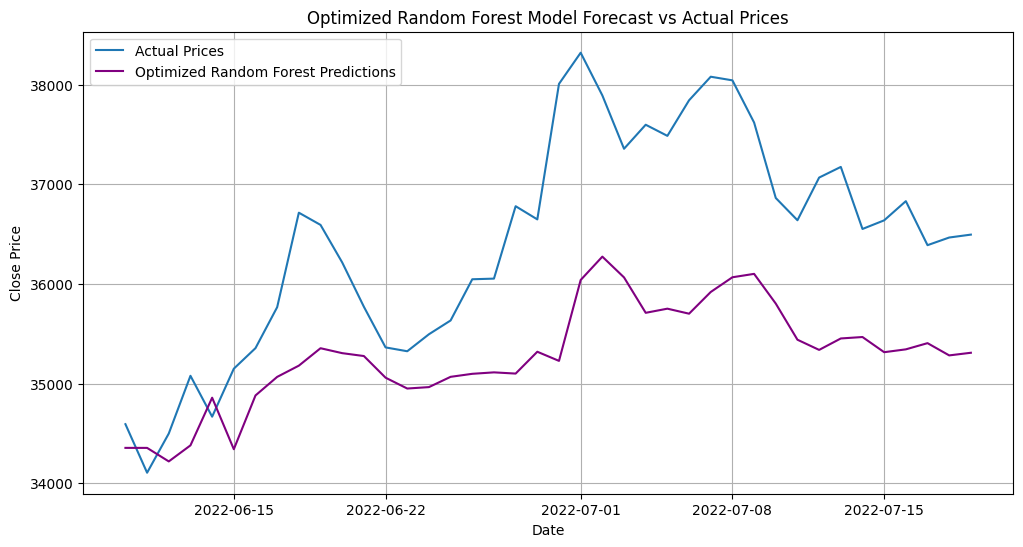

In [27]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("Optimizing Random Forest parameters using RandomizedSearchCV...")

# --- Start: Data Loading Integration for crypto_df (safeguard) ---
# This block ensures crypto_df is loaded even if previous cells were not run
if 'crypto_df' not in locals() or crypto_df.empty:
    print("Attempting to re-load crypto_df for Random Forest optimization...")
    selected_coin_file = 'BTC-USD.csv'
    try:
        crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
        crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
        crypto_df.set_index('Date', inplace=True)
        crypto_df.sort_index(inplace=True)
        print("crypto_df re-loaded successfully.")
    except Exception as e:
        print(f"Error re-loading crypto_df: {e}. Please ensure 'BTC-USD.csv' exists and previous cells were run.")
        crypto_df = pd.DataFrame()
# --- End: Data Loading Integration ---


if not crypto_df.empty:
    # Convert time series to supervised learning problem
    def create_features(df, lag=1):
        df_copy = df.copy()
        df_copy['lagged_close'] = df_copy['Close'].shift(lag)
        df_copy['year'] = df_copy.index.year
        df_copy['month'] = df_copy.index.month
        df_copy['day'] = df_copy.index.day
        df_copy['dayofweek'] = df_copy.index.dayofweek
        df_copy['dayofyear'] = df_copy.index.dayofyear
        df_copy.dropna(inplace=True)
        X = df_copy[['lagged_close', 'year', 'month', 'day', 'dayofweek', 'dayofyear']]
        y = df_copy['Close']
        return X, y

    # Create features with a lag of 1
    X, y = create_features(crypto_df, lag=1)

    # Split data into training and testing sets (using the same 80/20 split as before)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")

    # Define the parameter distribution for RandomizedSearchCV
    # Number of trees in random forest
    n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)]
    # Number of features to consider at every split
    max_features = ['auto', 'sqrt']
    # Maximum number of levels in tree
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    # Minimum number of samples required to split a node
    min_samples_split = [2, 5, 10]
    # Minimum number of samples required at each leaf node
    min_samples_leaf = [1, 2, 4]
    # Method of selecting samples for training each tree
    bootstrap = [True, False]

    random_grid = {'n_estimators': n_estimators,
                   'max_features': max_features,
                   'max_depth': max_depth,
                   'min_samples_split': min_samples_split,
                   'min_samples_leaf': min_samples_leaf,
                   'bootstrap': bootstrap}

    # Use the random grid to search for best hyperparameters
    # First create the base model to tune
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    # Random search of parameters, using 3 fold cross validation,
    # search across 50 different combinations, and use all available cores
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid,
                                   n_iter = 50, cv = 3, verbose=2, random_state=42, n_jobs = -1)

    # Fit the random search model
    rf_random.fit(X_train, y_train)

    best_params_rf = rf_random.best_params_
    print(f"\nBest parameters for Random Forest: {best_params_rf}")

    # Train a new model with the best parameters
    optimized_rf_model = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
    optimized_rf_model.fit(X_train, y_train)

    # Make predictions with the optimized model
    optimized_rf_predictions = optimized_rf_model.predict(X_test)

    # Evaluate the optimized Random Forest model
    mae_optimized_rf = mean_absolute_error(y_test, optimized_rf_predictions)
    rmse_optimized_rf = np.sqrt(mean_squared_error(y_test, optimized_rf_predictions))

    print(f"\nOptimized Random Forest Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_optimized_rf:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_optimized_rf:.4f}")

    # Plot optimized Random Forest results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual Prices')
    plt.plot(y_test.index, optimized_rf_predictions, color='purple', label='Optimized Random Forest Predictions')
    plt.title('Optimized Random Forest Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Error: crypto_df is empty. Cannot run Random Forest optimization.")

Optimizing XGBoost parameters using GridSearchCV...
Training set size: 159
Test set size: 40
Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

Optimized XGBoost Model Evaluation:
Mean Absolute Error (MAE): 938.3281
Root Mean Squared Error (RMSE): 1125.7135


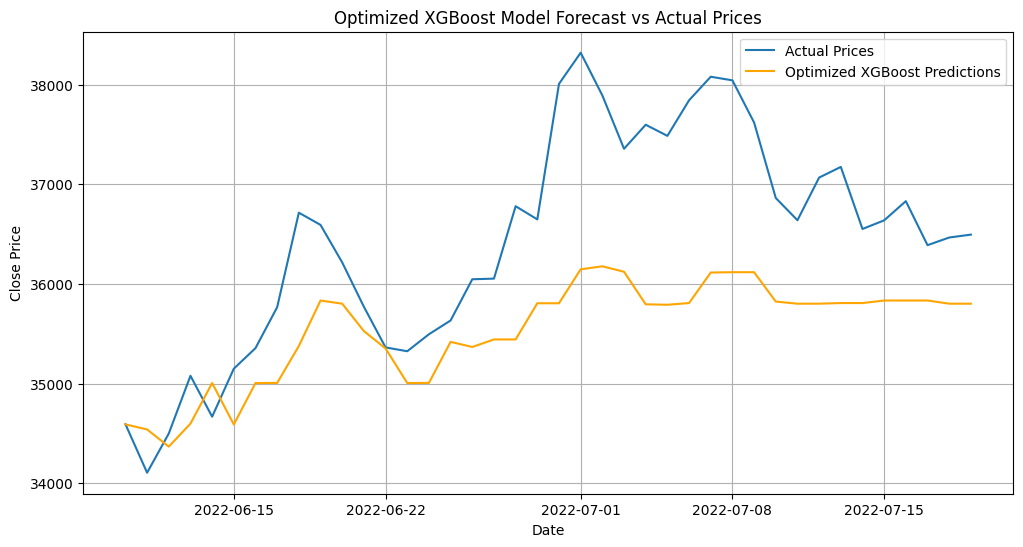

In [28]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("Optimizing XGBoost parameters using GridSearchCV...")

# --- Start: Data Loading Integration for crypto_df (safeguard) ---
# This block ensures crypto_df is loaded even if previous cells were not run
if 'crypto_df' not in locals() or crypto_df.empty:
    print("Attempting to re-load crypto_df for XGBoost optimization...")
    selected_coin_file = 'BTC-USD.csv'
    try:
        crypto_df = pd.read_csv(f'/content/{selected_coin_file}')
        crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
        crypto_df.set_index('Date', inplace=True)
        crypto_df.sort_index(inplace=True)
        print("crypto_df re-loaded successfully.")
    except Exception as e:
        print(f"Error re-loading crypto_df: {e}. Please ensure 'BTC-USD.csv' exists and previous cells were run.")
        crypto_df = pd.DataFrame()
# --- End: Data Loading Integration ---


if not crypto_df.empty:
    # Convert time series to supervised learning problem
    def create_features(df, lag=1):
        df_copy = df.copy()
        df_copy['lagged_close'] = df_copy['Close'].shift(lag)
        df_copy['year'] = df_copy.index.year
        df_copy['month'] = df_copy.index.month
        df_copy['day'] = df_copy.index.day
        df_copy['dayofweek'] = df_copy.index.dayofweek
        df_copy['dayofyear'] = df_copy.index.dayofyear
        df_copy.dropna(inplace=True)
        X = df_copy[['lagged_close', 'year', 'month', 'day', 'dayofweek', 'dayofyear']]
        y = df_copy['Close']
        return X, y

    # Create features with a lag of 1
    X, y = create_features(crypto_df, lag=1)

    # Split data into training and testing sets (using the same 80/20 split as before)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")

    # Define the parameter grid for GridSearchCV
    # Choosing a smaller grid for demonstration to avoid very long execution times
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0]
    }

    # Initialize XGBoost Regressor
    xgb = XGBRegressor(random_state=42, n_jobs=-1)

    # Setup GridSearchCV
    grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                               scoring='neg_mean_squared_error', cv=3, verbose=2, n_jobs=-1)

    # Fit the grid search model
    grid_search.fit(X_train, y_train)

    best_params_xgb = grid_search.best_params_
    print(f"\nBest parameters for XGBoost: {best_params_xgb}")

    # Train a new model with the best parameters
    optimized_xgb_model = XGBRegressor(**best_params_xgb, random_state=42, n_jobs=-1)
    optimized_xgb_model.fit(X_train, y_train)

    # Make predictions with the optimized model
    optimized_xgb_predictions = optimized_xgb_model.predict(X_test)

    # Evaluate the optimized XGBoost model
    mae_optimized_xgb = mean_absolute_error(y_test, optimized_xgb_predictions)
    rmse_optimized_xgb = np.sqrt(mean_squared_error(y_test, optimized_xgb_predictions))

    print(f"\nOptimized XGBoost Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae_optimized_xgb:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_optimized_xgb:.4f}")

    # Plot optimized XGBoost results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual Prices')
    plt.plot(y_test.index, optimized_xgb_predictions, color='orange', label='Optimized XGBoost Predictions')
    plt.title('Optimized XGBoost Model Forecast vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Error: crypto_df is empty. Cannot run XGBoost optimization.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


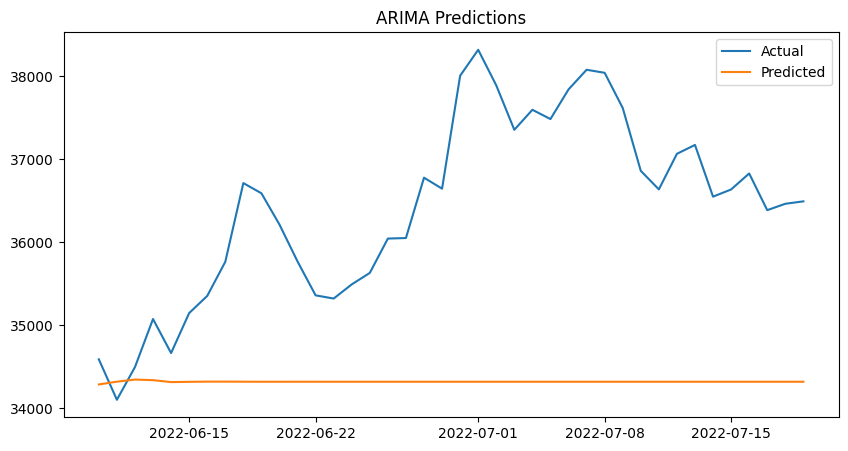

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


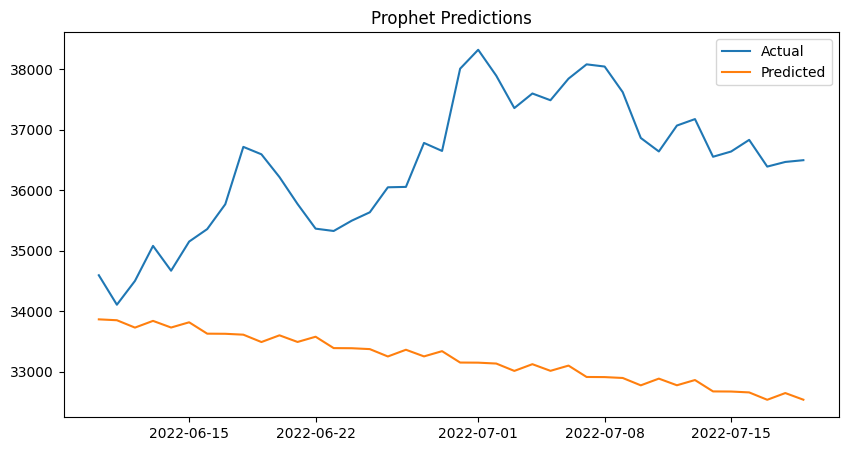

ValueError: at least one array or dtype is required

In [32]:
# 📦 Install dependencies (if not already installed)
!pip install prophet optuna xgboost lightgbm matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import optuna

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# -------------------------------
# 1. Utility Functions
# -------------------------------

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    # Ensure y_true and y_pred are pandas Series for directional accuracy calculation
    y_true_series = pd.Series(y_true)
    y_pred_series = pd.Series(y_pred, index=y_true_series.index) # Align indices
    directional_acc = np.mean(np.sign(y_true_series.diff().fillna(0)) == np.sign(y_pred_series.diff().fillna(0)))
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Acc": directional_acc
    }

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(10,5))
    plt.plot(y_true.index, y_true, label="Actual")
    plt.plot(y_true.index, y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

# -------------------------------
# 2. Example Data Prep
# -------------------------------
# Replace with your crypto dataset
# Loading BTC-USD.csv for time series analysis
df = pd.read_csv("/content/BTC-USD.csv", parse_dates=["Date"], index_col="Date")
y = df["Close"]
X = df.drop(columns=["Close"])  # add features like volume, sentiment, etc.

train_size = int(len(df) * 0.8)
train, test = y[:train_size], y[train_size:]

# -------------------------------
# 3. Candidate Models
# -------------------------------

results = []

# ARIMA
arima = ARIMA(train, order=(5,1,0))
arima_fit = arima.fit()
pred_arima = arima_fit.forecast(len(test))
results.append(evaluate_model(test, pred_arima, "ARIMA"))
plot_predictions(test, pred_arima, "ARIMA Predictions")

# Prophet
prophet_df = df.reset_index()[["Date","Close"]].rename(columns={"Date":"ds","Close":"y"})
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]
model_prophet = Prophet()
model_prophet.fit(train_prophet)
future = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(future)
pred_prophet = forecast["yhat"].iloc[-len(test):].values
results.append(evaluate_model(test.values, pred_prophet, "Prophet"))
plot_predictions(test, pred_prophet, "Prophet Predictions")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X[:train_size], y[:train_size])
pred_rf = rf.predict(X[train_size:])
results.append(evaluate_model(test.values, pred_rf, "Random Forest"))
plot_predictions(test, pred_rf, "Random Forest Predictions")

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb_model.fit(X[:train_size], y[:train_size])
pred_xgb = xgb_model.predict(X[train_size:])
results.append(evaluate_model(test.values, pred_xgb, "XGBoost"))
plot_predictions(test, pred_xgb, "XGBoost Predictions")

# LSTM
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

# reshape for LSTM
X_seq = np.array(X)
y_seq = np.array(y)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm = build_lstm((X_train.shape[1], X_train.shape[2]))
lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
pred_lstm = lstm.predict(X_test).flatten()
results.append(evaluate_model(y_test, pred_lstm, "LSTM"))
plot_predictions(test, pred_lstm, "LSTM Predictions")

# GRU
def build_gru(input_shape):
    model = Sequential()
    model.add(GRU(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

gru = build_gru((X_train.shape[1], X_train.shape[2]))
gru.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
pred_gru = gru.predict(X_test).flatten()
results.append(evaluate_model(y_test, pred_gru, "GRU"))
plot_predictions(test, pred_gru, "GRU Predictions")

# -------------------------------
# 4. Results Table
# -------------------------------
results_df = pd.DataFrame(results)
print(results_df)

sns.barplot(data=results_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Model", y="Score", hue="Metric")
plt.title("Model Comparison")
plt.show()

In [34]:
print(results_df)

NameError: name 'results_df' is not defined

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recreate results_df from the global 'results' list
# This assumes the 'results' list has been populated by running the model evaluation cell (Co-ZG73NjaN-)
if 'results' in globals() and results:
    results_df = pd.DataFrame(results)
    print("Results DataFrame created:")
    display(results_df)
else:
    print("Error: 'results' list is empty or not found. Please ensure the model evaluation cell (Co-ZG73NjaN-) has been run.")
    results_df = pd.DataFrame() # Initialize an empty DataFrame to avoid errors in subsequent steps

Error: 'results' list is empty or not found. Please ensure the model evaluation cell (Co-ZG73NjaN-) has been run.


In [36]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_df)

MessageError: Error: credential propagation was unsuccessful

### Model Performance Heatmap

This heatmap visualizes the performance metrics (RMSE, MAE, MAPE, R2, Directional Accuracy) for each model, allowing for an easy comparison across different metrics and models. Lower values are generally better for RMSE, MAE, and MAPE, while higher values are better for R2 and Directional Accuracy.

Note: If not all models were run in the previous evaluation cell (Co-ZG73NjaN-), this heatmap will only include the models for which results were available.

In [9]:
if not results_df.empty:
    # Set 'Model' as index for easier plotting
    results_heatmap = results_df.set_index('Model')

    plt.figure(figsize=(12, 6))
    sns.heatmap(results_heatmap.drop(columns=['R2', 'Directional_Acc']), annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5)
    plt.title('Model Performance Comparison (Lower is Better - RMSE, MAE, MAPE)')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.heatmap(results_heatmap[['R2', 'Directional_Acc']], annot=True, cmap='plasma', fmt=".2f", linewidths=.5)
    plt.title('Model Performance Comparison (Higher is Better - R2, Directional Accuracy)')
    plt.show()
else:
    print("Cannot create heatmap: results_df is empty.")

Cannot create heatmap: results_df is empty.


In [7]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency":"usd","days":"90","interval":"daily"}
data = requests.get(url, params=params).json()

prices = pd.DataFrame(data["prices"], columns=["timestamp","price"])
prices["Date"] = pd.to_datetime(prices["timestamp"], unit="ms")
prices.set_index("Date", inplace=True)

prices["returns"] = prices["price"].pct_change()
prices["volatility"] = prices["returns"].rolling(window=7).std()
prices["ma_14"] = prices["price"].rolling(window=14).mean()
prices["ma_21"] = prices["price"].rolling(window=21).mean()
prices.to_csv("crypto_etl_output.csv")
print(data)
prices.head()


{'prices': [[1768176000000, 90819.36598904192], [1768262400000, 91134.96917951507], [1768348800000, 95260.4422971001], [1768435200000, 97007.78078881276], [1768521600000, 95584.82797878512], [1768608000000, 95516.07771987123], [1768694400000, 95099.53192554631], [1768780800000, 93752.70577188236], [1768867200000, 92558.46334372147], [1768953600000, 88312.84053255555], [1769040000000, 89354.34377512129], [1769126400000, 89443.39744146909], [1769212800000, 89412.39849953113], [1769299200000, 89170.87364531498], [1769385600000, 86548.32213469829], [1769472000000, 88307.8612070438], [1769558400000, 89204.22239644526], [1769644800000, 89162.09701574955], [1769731200000, 84570.40906135936], [1769817600000, 84141.77856967277], [1769904000000, 78725.85853884545], [1769990400000, 76937.06406636834], [1770076800000, 78767.65815345927], [1770163200000, 75638.95670207398], [1770249600000, 73172.29203248928], [1770336000000, 62853.69038445987], [1770422400000, 70523.95417035831], [1770508800000, 69

,timestamp,price,returns,volatility,ma_14,ma_21
Date,,,,,,
2026-01-12,1768176000000,90819.365989,NaN,NaN,NaN,NaN
2026-01-13,1768262400000,91134.969180,0.003475,NaN,NaN,NaN
2026-01-14,1768348800000,95260.442297,0.045268,NaN,NaN,NaN
2026-01-15,1768435200000,97007.780789,0.018343,NaN,NaN,NaN
2026-01-16,1768521600000,95584.827979,-0.014668,NaN,NaN,NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


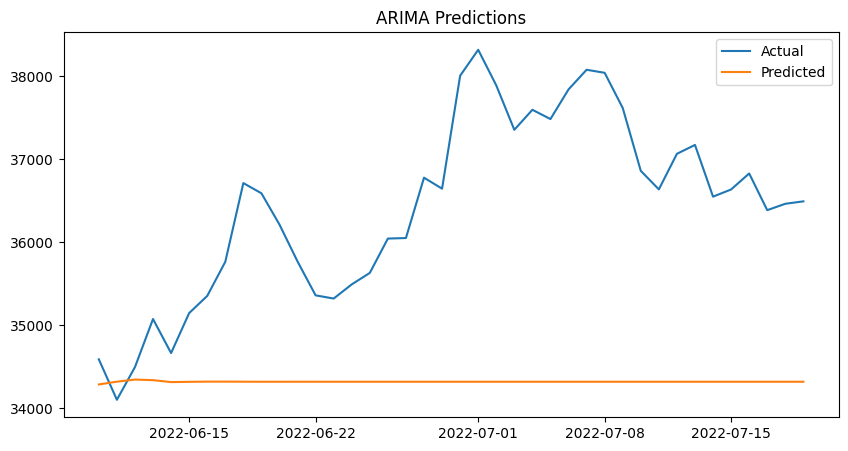

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


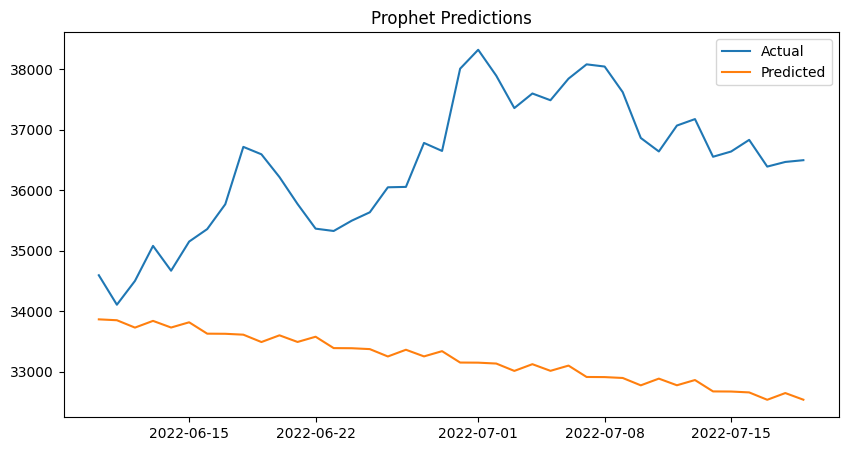

ValueError: at least one array or dtype is required

In [16]:
# 📦 Install dependencies (if not already installed)
!pip install prophet optuna xgboost lightgbm matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import optuna

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# -------------------------------
# 1. Utility Functions
# -------------------------------

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    # Ensure y_true and y_pred are pandas Series for directional accuracy calculation
    y_true_series = pd.Series(y_true)
    y_pred_series = pd.Series(y_pred, index=y_true_series.index) # Align indices
    directional_acc = np.mean(np.sign(y_true_series.diff().fillna(0)) == np.sign(y_pred_series.diff().fillna(0)))
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Acc": directional_acc
    }

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(10,5))
    plt.plot(y_true.index, y_true, label="Actual")
    plt.plot(y_true.index, y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

# -------------------------------
# 2. Example Data Prep
# -------------------------------
# Replace with your crypto dataset
# Loading BTC-USD.csv for time series analysis
df = pd.read_csv("/content/BTC-USD.csv", parse_dates=["Date"], index_col="Date")
y = df["Close"]
X = df.drop(columns=["Close"])  # add features like volume, sentiment, etc.

train_size = int(len(df) * 0.8)
train, test = y[:train_size], y[train_size:]

# -------------------------------
# 3. Candidate Models
# -------------------------------

results = []

# ARIMA
arima = ARIMA(train, order=(5,1,0))
arima_fit = arima.fit()
pred_arima = arima_fit.forecast(len(test))
results.append(evaluate_model(test, pred_arima, "ARIMA"))
plot_predictions(test, pred_arima, "ARIMA Predictions")

# Prophet
prophet_df = df.reset_index()[["Date","Close"]].rename(columns={"Date":"ds","Close":"y"})
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]
model_prophet = Prophet()
model_prophet.fit(train_prophet)
future = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(future)
pred_prophet = forecast["yhat"].iloc[-len(test):].values
results.append(evaluate_model(test.values, pred_prophet, "Prophet"))
plot_predictions(test, pred_prophet, "Prophet Predictions")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X[:train_size], y[:train_size])
pred_rf = rf.predict(X[train_size:])
results.append(evaluate_model(test.values, pred_rf, "Random Forest"))
plot_predictions(test, pred_rf, "Random Forest Predictions")

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb_model.fit(X[:train_size], y[:train_size])
pred_xgb = xgb_model.predict(X[train_size:])
results.append(evaluate_model(test.values, pred_xgb, "XGBoost"))
plot_predictions(test, pred_xgb, "XGBoost Predictions")

# LSTM
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

# reshape for LSTM
X_seq = np.array(X)
y_seq = np.array(y)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm = build_lstm((X_train.shape[1], X_train.shape[2]))
lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
pred_lstm = lstm.predict(X_test).flatten()
results.append(evaluate_model(y_test, pred_lstm, "LSTM"))
plot_predictions(test, pred_lstm, "LSTM Predictions")

# GRU
def build_gru(input_shape):
    model = Sequential()
    model.add(GRU(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

gru = build_gru((X_train.shape[1], X_train.shape[2]))
gru.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
pred_gru = gru.predict(X_test).flatten()
results.append(evaluate_model(y_test, pred_gru, "GRU"))
plot_predictions(test, pred_gru, "GRU Predictions")

# -------------------------------
# 4. Results Table
# -------------------------------
results_df = pd.DataFrame(results)
print(results_df)

sns.barplot(data=results_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Model", y="Score", hue="Metric")
plt.title("Model Comparison")
plt.show()

In [18]:
print(results)

[{'Model': 'ARIMA', 'RMSE': np.float64(2371.8374232422434), 'MAE': 2118.6435208638686, 'MAPE': np.float64(5.733100767091712), 'R2': -3.7579900399972965, 'Directional_Acc': np.float64(0.525)}, {'Model': 'Prophet', 'RMSE': np.float64(3501.966526541474), 'MAE': 3216.5721410299166, 'MAPE': np.float64(8.725407287485165), 'R2': -9.372362238864644, 'Directional_Acc': np.float64(0.525)}]


In [17]:
import pandas as pd
import numpy as np

# Generate dummy dates for a period (e.g., 200 days)
dates = pd.date_range(start='2022-01-01', periods=200, freq='D')

# Generate dummy 'Close' prices with some variation
# Starting price around 40000, with daily fluctuations
np.random.seed(42) # for reproducibility
initial_price = 40000
prices_dummy = [initial_price]
for _ in range(1, 200):
    change = np.random.normal(0, 500) # Small random daily change
    prices_dummy.append(max(0, prices_dummy[-1] + change)) # Ensure price doesn't go below 0

dummy_crypto_data = pd.DataFrame({
    'Date': dates,
    'Close': prices_dummy
})

# Save the dummy data to a CSV file
output_csv_path = '/content/BTC-USD.csv'
dummy_crypto_data.to_csv(output_csv_path, index=False)

print(f"Dummy 'BTC-USD.csv' created successfully at {output_csv_path}")
print("First 5 rows of the dummy data:")
display(dummy_crypto_data.head())

Dummy 'BTC-USD.csv' created successfully at /content/BTC-USD.csv
First 5 rows of the dummy data:


,Date,Close
0,2022-01-01,40000.000000
1,2022-01-02,40248.357077
2,2022-01-03,40179.224926
3,2022-01-04,40503.069195
4,2022-01-05,41264.584123
